## Load libraries and modules

In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
from numpy import sin, cos, pi

# Metrics

In [2]:
from sklearn.metrics import r2_score as r2, mean_absolute_error as mae, mean_squared_error as mse, root_mean_squared_error as rmse

In [3]:
def rel_err(y_true,y_pred):
    return np.abs((y_true - y_pred)/y_true)

def rmse_pt(y_true,y_pred):
    return np.abs(y_true - y_pred)

# Model
## Noiseless model

In [4]:
def analytical(theta:float,beta:float,alpha:float):
    return (\
        cos(alpha)**4 + sin(alpha)**4 +\
        2 * (sin(alpha)**2) * (cos(alpha)**2) * cos(theta) + \
        cos(alpha+beta)**4 + sin(alpha+beta)**4 + \
        2 * (sin(alpha+beta)**2) * (cos(alpha+beta)**2) * cos(theta)\
        )/2

## Noise-based Model

# Data description

| path | Description  | noise $\%$|
|---------------------|-------------|-------------|
|`runs`               | gridsize $20^{2}$ N_states = 1,5,10,15,20,25,30,35,40,45 (K)  | $\begin{pmatrix}0& 0.1& 4 \end{pmatrix}$|
|`runs`               | Probabilities taken from Chen's paper and tiny noise  | $\begin{pmatrix}0& 0.1& 4 \end{pmatrix}$|
|`fixed point`        | $\theta=\pi/3$, $\beta = \pi/4$ non parametrized| $\begin{pmatrix}0 & 0.1 & 0.2 \end{pmatrix}$|
|`fixed error results`| bad simulations with inconsistent number of states and different grid sizes | 30  too much  |

In [5]:
reviewed_probability_filenames = pd.read_csv("./runs/filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()
noisy_probability_filenames = pd.read_csv("./runs/noisy_filenames.csv",header=None).dropna(axis=1,how='all').values.flatten()

## Join data in concatenated Data Frames

In [6]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

path = './runs/'
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

noiseless_r2 = list()
noiseless_mse = list()
noiseless_rmse = list()

noisy_r2 = list()
noisy_mse = list()
noisy_rmse = list()

model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

for experiment_name in reviewed_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    noiseless_r2.append( 1-r2(y_true=model,y_pred=experiment) )
    noiseless_mse.append( (mse(y_true=model,y_pred=experiment) ))
    noiseless_rmse.append( (rmse(y_true=model,y_pred=experiment) ))

for experiment_name in noisy_probability_filenames:
    experiment = pd.read_csv(path+experiment_name, header=None).dropna(axis=1,how='all').values    
    noisy_r2.append( 1-r2(y_true=model,y_pred=experiment) )
    noisy_mse.append( mse(y_true=model,y_pred=experiment) )
    noisy_rmse.append( rmse(y_true=model,y_pred=experiment) )
    
"""
N_states = pd.DataFrame(dict(zip(['N_states'],[[1.0E3,5.0E3,1.0E4,1.5E4,2.0E4,2.5E4,3.0E4,3.5E4,4.0E4,4.5E4]])))
df_reviewed = pd.DataFrame( dict(zip(['Noise','R2','RMSE','MSE'],[[0.0 for k in range(len (noiseless_mse))],noiseless_r2,noiseless_rmse,noiseless_mse])) )
df_noisy = pd.DataFrame( dict(zip(['Noise','R2','RMSE','MSE'],[[9.0 for k in range(len(noisy_mse))],noisy_r2,noisy_rmse,noisy_mse])) )
"""
N_states_list = [1.0E3, 5.0E3, 1.0E4, 1.5E4, 2.0E4, 2.5E4, 3.0E4, 3.5E4, 4.0E4, 4.5E4]

df_reviewed = pd.DataFrame({
    'Noise': 0.0,
    'R2': noiseless_r2,
    'RMSE': noiseless_rmse,
    'MSE': noiseless_mse,
    'N_states': N_states_list
})

df_noisy = pd.DataFrame({
    'Noise': 9.0,
    'R2': noisy_r2,
    'RMSE': noisy_rmse,
    'MSE': noisy_mse,
    'N_states': N_states_list
})

# Concatenamos de forma limpia
results = pd.concat([df_reviewed, df_noisy], ignore_index=True)

# Plots

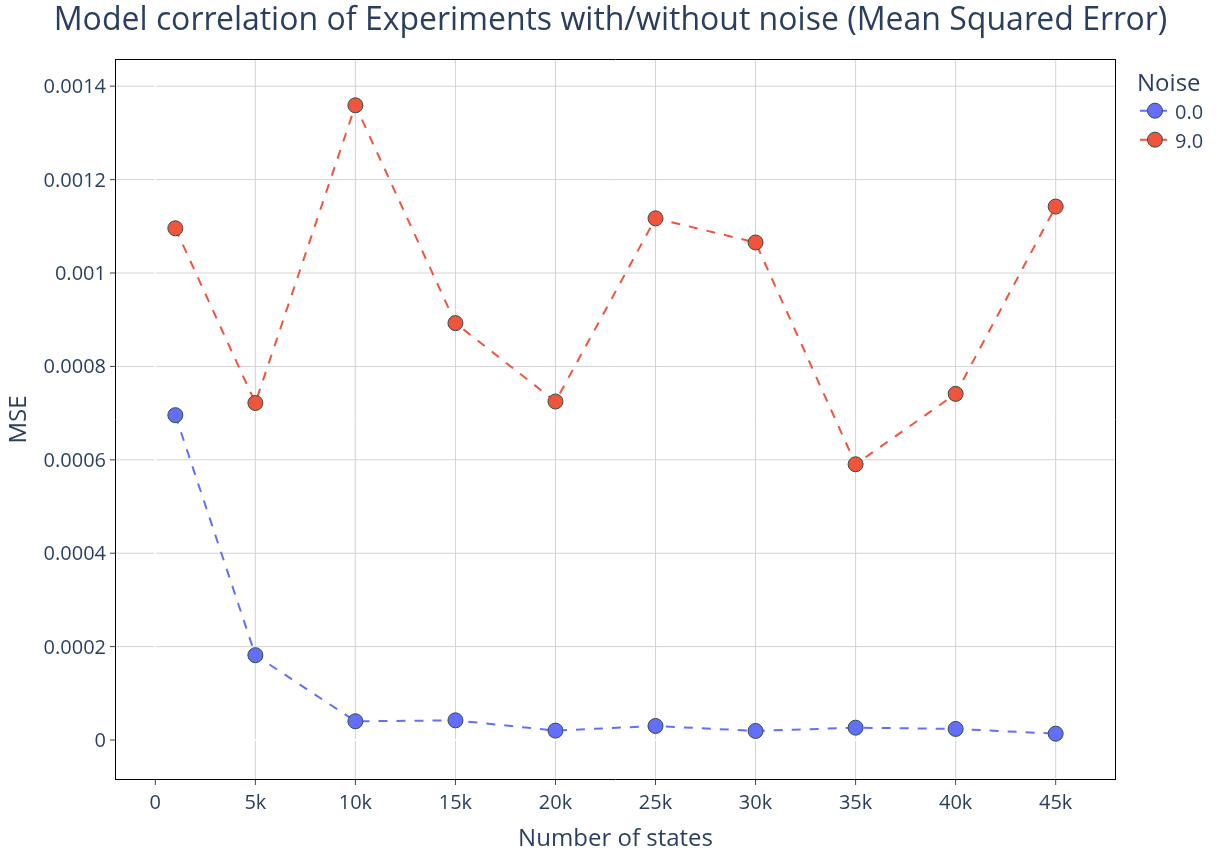

In [7]:
# Configuración del subplot
fig = px.line(results,
              x = 'N_states',
              y = 'MSE',
              color = 'Noise',
              markers = True
              )
fig.update_traces(marker=dict(size=15,line=dict(width=1, color='DarkSlateGrey')),
                  line_dash='dash'
                 )
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise (Mean Squared Error)",
        'font': {'size': 32},
        'x' :0.5
    }
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    #type='log',
    title_text='MSE',
    #title_text='Log  (MSE)'
)
#fig.add_hline(y=0, line_width=3, line_dash="dash", line_color="lightgrey", annotation_text="Target MSE", annotation_position="top left")
fig.show()

### scalation of metrics to reduce dispersion and enhance visualization

In [8]:
from sklearn.preprocessing import StandardScaler as zscaler

In [9]:
# Create an empty DataFrame with the exact same index as 'results'
scaled_results = pd.DataFrame(index=results.index, columns=['R2 scaled', 'RMSE scaled', 'MSE scaled'])

# Create masks to isolate each experiment
mask_0 = results['Noise'] == 0.0
mask_9 = results['Noise'] == 9.0

# Initialize independent scalers
scaler_0 = zscaler()
scaler_9 = zscaler()

# Fit and transform independently, then assign back
scaled_results.loc[mask_0, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_0.fit_transform(results.loc[mask_0, ['R2', 'RMSE', 'MSE']])
scaled_results.loc[mask_9, ['R2 scaled', 'RMSE scaled', 'MSE scaled']] = scaler_9.fit_transform(results.loc[mask_9, ['R2', 'RMSE', 'MSE']])

# Ensure the columns are strictly float types so Plotly handles them correctly
scaled_results = scaled_results.astype(float)

In [10]:
results_df = pd.concat([results, scaled_results], axis=1)
results_df.describe()

,Noise,R2,RMSE,MSE,N_states,R2 scaled,RMSE scaled,MSE scaled
count,20.000000,20.000000,20.000000,20.000000,20.000000,2.000000e+01,2.000000e+01,2.000000e+01
mean,4.500000,0.160560,0.018695,0.000527,22600.000000,1.665335e-16,3.996803e-16,3.330669e-16
std,4.616903,0.171096,0.012585,0.000483,14576.116009,1.025978e+00,1.025978e+00,1.025978e+00
min,0.000000,0.001652,0.003482,0.000014,1000.000000,-2.026209e+00,-1.557520e+00,-1.518178e+00
25%,0.000000,0.003458,0.004932,0.000029,10000.000000,-4.208471e-01,-5.716272e-01,-4.543081e-01
50%,4.500000,0.088088,0.024264,0.000643,22500.000000,-3.416103e-01,-3.207064e-01,-3.691365e-01
75%,9.000000,0.293550,0.029517,0.000936,35000.000000,1.990313e-01,6.642652e-01,5.477841e-01
max,9.000000,0.456685,0.036601,0.001359,45000.000000,2.962199e+00,2.772724e+00,2.917231e+00


## Metrics dispersion

In [11]:
tick_values = [k for k in range(-3,4)]
tick_labels = ['0' if val == 0 else f'{val}σ' for val in tick_values]

fig = px.box(results_df,
       y = ['MSE scaled', 'RMSE scaled','R2 scaled'],
       points='all',
             color='Noise',
       height = 844,
       width = 1500,
            )
fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')),
                  selector=dict(type='box'))

fig.update_layout(
    title={
        'text': "Dispersion of Standardized Error and Fit Metrics by Noise Level",
        'font': {'size': 32},
        'x' :0.5
    },
    font=dict(size=25),
    plot_bgcolor='white',
    paper_bgcolor='white'
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    title_text='Metric',
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    zerolinecolor='LightGray', 
    zerolinewidth=1,
    linecolor='black',
    gridcolor='lightgrey',
    tickmode='array', # Explicitly set tickmode to 'array'
    tickvals=tick_values,
    ticktext=tick_labels,
)
fig.show()

## Messy results

In [12]:
path = 'fixed error results/'


pure_filenames = ['pure_50x50_mesh_1E3_states_E91_data_2026_aer_simulator_25_02_2026_12_56_22',
                  'pure_50x50_mesh_5E3_states_E91_data_2026_aer_simulator_25_02_2026_14_33_00',
                  'pure_50x50_mesh_1E4_states_E91_data_2026_aer_simulator_25_02_2026_20_10_04',
                  'pure_50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_26_02_2026_15_59_56',
                  'pure_50x50_mesh_2E4_states_E91_data_2026_aer_simulator_25_02_2026_22_54_49']

error_filenames= ['50x50_mesh_1E3_states_E91_data_2026_aer_simulator_23_02_2026_18_32_14',
                  '50x50_mesh_5E3_states_E91_data_2026_aer_simulator_23_02_2026_14_22_55',
                  '50x50_mesh_1E4_estates_E91_data_2026_aer_simulator_23_02_2026_14_36_26',
                  '50x50_mesh_1.5E4_states_E91_data_2026_aer_simulator_23_02_2026_23_12_07',
                  '50x50_mesh_2E4_states_E91_data_2026_aer_simulator_24_02_2026_07_12_29',
                  '50x50_mesh_2.5E4_states_E91_data_2026_aer_simulator_24_02_2026_11_27_03']

test_filenames= ['10x10_mesh_1E3_E91_data_2026_aer_simulator_02_03_2026_15_36_28',
                 '10x10_mesh_1E4_states_E91_data_2026_aer_simulator_02_03_2026_16_23_52',
                 '10x10_mesh_1.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_08_36',
                 '10x10_mesh_2E4_states_E91_data_2026_aer_simulator_02_03_2026_19_41_56',
                 '10x10_mesh_2.5E4_states_E91_data_2026_aer_simulator_02_03_2026_19_04_56',
                 '10x10_3E4_states_E91_data_2026_aer_simulator_02_03_2026_15_54_44',
                 '10x10_mesh_3.5E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_08',
                 '10x10_mesh_4E4_states_E91_data_2026_aer_simulator_03_03_2026_00_58_51',]

# DataFrame Formation

In [17]:
N_data = 20

theta_FSS = np.linspace(0, 2*pi, N_data)
beta_angle = np.linspace(0, pi, N_data)
alpha = pi/16

# Base model (from your original code)
experiment_number = 5
model = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

# Initialize metric lists
correlation_10_error = []
mse_10_error = []
r2_10_error = []

correlation_50_error = []
mse_50_error = []
r2_50_error = []

correlation_50_pure = []
mse_50_pure = []
r2_50_pure = []

mse_15_tiny_noise = []
correlation_15_tiny_noise = []
r2_15_tiny_noise = []

mse_20_tiny_noise = []
correlation_20_tiny_noise = []
r2_20_tiny_noise = []

rel_err_single_pt = []

# =========================================================
# OPTIMIZATION: Calculate static ideal models ONCE here
# =========================================================
# 10x10 Model
theta_10 = np.linspace(0, 2*pi, 10)
beta_10 = np.linspace(0, pi, 10)
model_10_ideal = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_10] for t in theta_10])

# 50x50 Model (We can use this exact same model for both pure and error loops!)
theta_50 = np.linspace(0, 2*pi, 50)
beta_50 = np.linspace(0, pi, 50)
model_50_ideal = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_50] for t in theta_50])
# =========================================================

# Loop 1: test_filenames (10x10)
for experiment_name in test_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1, how='all').values    
    
    # Calculate and append metrics using the pre-calculated model
    correlation_10_error.append( rmse(y_true=model_10_ideal, y_pred=experiment) )
    mse_10_error.append( mse(y_true=model_10_ideal, y_pred=experiment) )
    r2_10_error.append( r2(y_true=model_10_ideal, y_pred=experiment) )
    
# Loop 2: error_filenames (50x50)
for experiment_name in error_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1, how='all').values
    
    # Calculate and append metrics using the pre-calculated model
    correlation_50_error.append( rmse(y_true=model_50_ideal, y_pred=experiment) )
    mse_50_error.append( mse(y_true=model_50_ideal, y_pred=experiment) )
    r2_50_error.append( r2(y_true=model_50_ideal, y_pred=experiment) )
    
# Loop 3: pure_filenames (50x50)
for experiment_name in pure_filenames:
    experiment = pd.read_csv(path+experiment_name+'.csv', header=None).dropna(axis=1, how='all').values
    
    # Calculate and append metrics using the pre-calculated model
    correlation_50_pure.append( rmse(y_true=model_50_ideal, y_pred=experiment) )
    mse_50_pure.append( mse(y_true=model_50_ideal, y_pred=experiment) )
    r2_50_pure.append( r2(y_true=model_50_ideal, y_pred=experiment) )

# Loop 4: tiny_noise runs (Dynamic sizes using len(experiment))
path1 = "./runs/"
for experiment_name in pd.read_csv(path1+'test_filenames.csv',header=None).values.flatten():
    experiment = pd.read_csv(path1+experiment_name, header=None).dropna(axis=1, how='all').values
    
    # This remains inside the loop because its dimension scales dynamically with len(experiment)
    dim = len(experiment)
    theta_dyn = np.linspace(0, 2*pi, dim)
    beta_dyn = np.linspace(0, pi, dim)
    model_dyn = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_dyn] for t in theta_dyn])
    
    # Calculate and append metrics
    correlation_15_tiny_noise.append( rmse(y_true=model_dyn, y_pred=experiment) )
    mse_15_tiny_noise.append( mse(y_true=model_dyn, y_pred=experiment) )
    r2_15_tiny_noise.append( 1 - r2(y_true=model_dyn, y_pred=experiment) )

for experiment_name in pd.read_csv(path1+'tiny_noise_filenames.csv',header=None).dropna(axis=1, how='all').values.flatten():
    experiment = pd.read_csv(path1+experiment_name, header=None).dropna(axis=1, how='all').values
    
    # This remains inside the loop because its dimension scales dynamically with len(experiment)
    dim = len(experiment)
    theta_dyn = np.linspace(0, 2*pi, dim)
    beta_dyn = np.linspace(0, pi, dim)
    model_dyn = np.array([[analytical(theta=t, beta=b, alpha=alpha) for b in beta_dyn] for t in theta_dyn])
    
    # Calculate and append metrics
    correlation_20_tiny_noise.append( rmse(y_true=model_dyn, y_pred=experiment) )
    mse_20_tiny_noise.append( mse(y_true=model_dyn, y_pred=experiment) )
    r2_20_tiny_noise.append( 1 - r2(y_true=model_dyn, y_pred=experiment) )
    

# Single point experiments
path2 = "./fixed point/"
for n,experiment_name in enumerate(pd.read_csv(path2+'filenames_fixed_point.csv',header=None).dropna(axis=1, how='all').values.flatten()):
    experiment = pd.read_csv(path2+experiment_name,header=None).dropna(axis=1, how='all').values.flatten()
    dim = len(experiment)
    model_single_pt = [analytical(theta=pi/3,beta=pi/4,alpha=alpha) for k in range(dim)]
    rel_err_single_pt.append([])
    for k in range(dim):
        rel_err_single_pt[n].append(rel_err(y_true=model_single_pt[k],y_pred=experiment[k]))

# ==========================
# Creación de los DataFrames
# ==========================

# BUG FIX: Added the missing df_10_error DataFrame back in!
df_10_error = pd.DataFrame({
    'Nstates': [1E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4], 
    'RMSE': correlation_10_error,
    'MSE': mse_10_error,
    'R2': r2_10_error
})

df_50_pure = pd.DataFrame({
    'Nstates': [1E3, 1E4, 1.5E4, 2E4, 2.5E4],
    'RMSE': correlation_50_pure,
    'MSE': mse_50_pure,
    'R2': r2_50_pure
})

df_50_error = pd.DataFrame({
    'Nstates': [1E3, 5E3, 1E4, 1.5E4, 2E4, 2.5E4],
    
    'RMSE': correlation_50_error,
    'MSE': mse_50_error,
    'R2': r2_50_error
})

df_15_tiny_noise = pd.DataFrame({
    'Nstates': [1E3, 5E3, 1E4],
    'RMSE': correlation_15_tiny_noise,
    'MSE': mse_15_tiny_noise,
    'R2': r2_15_tiny_noise
})

df_20_tiny_noise = pd.DataFrame({
    'Nstates': [1E3,5E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4, 4.5E4],
    'RMSE': correlation_20_tiny_noise,
    'MSE': mse_20_tiny_noise,
    'R2': r2_20_tiny_noise
})

df_single_pt = pd.DataFrame({
    'Nstates': [1E3,5E3, 1E4, 1.5E4, 2E4, 2.5E4, 3E4, 3.5E4, 4E4, 4.5E4], 
    'run 1': rel_err_single_pt[0],
    'run 2': rel_err_single_pt[1],
    'run 3': rel_err_single_pt[2]
})

## Contrast All results

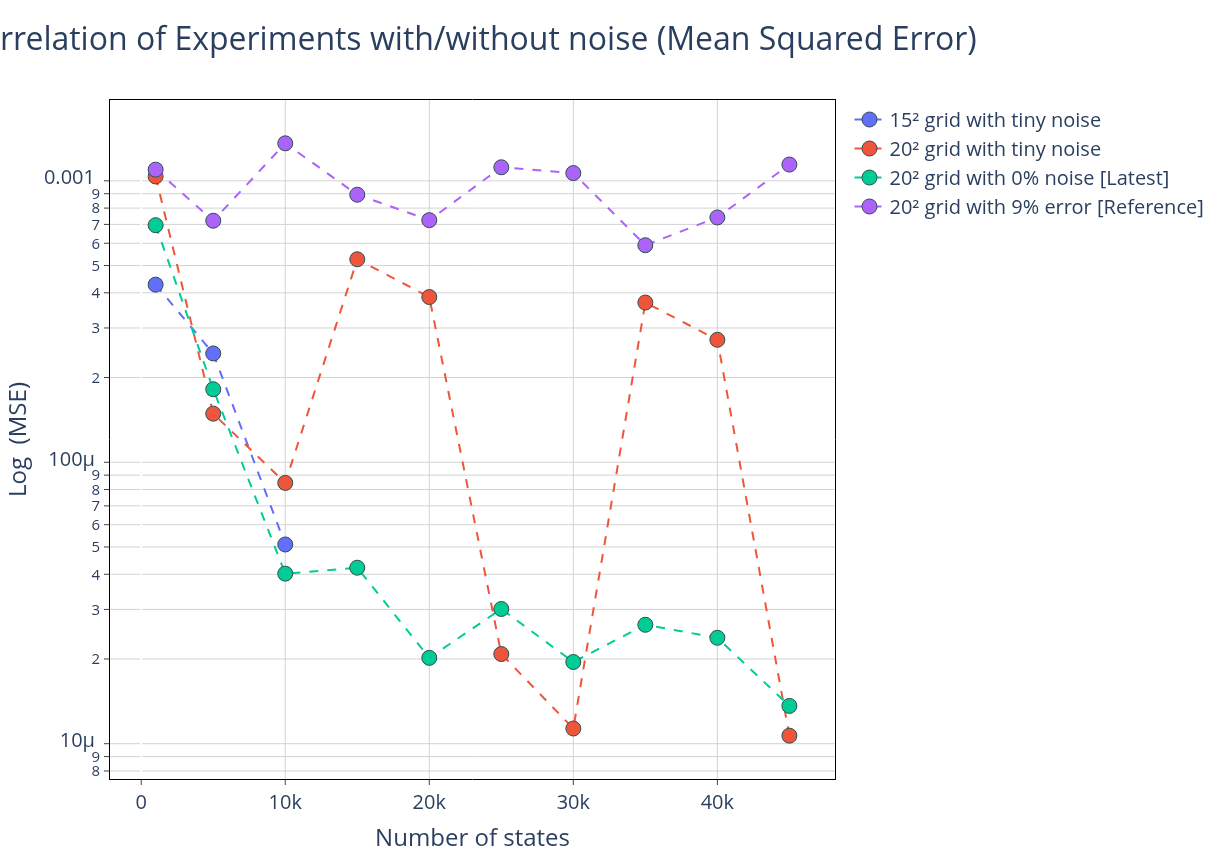

In [18]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)
"""
# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_50_pure['Nstates'], 
        y=df_50_pure['MSE'], 
        mode='lines+markers', 
        name='50² grid with 0% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la segunda fila (row=2)
fig.add_trace(
    go.Scatter(
        x=df_50_error['Nstates'], 
        y=df_50_error['MSE'], 
        mode='lines+markers', 
        name='50² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la tercera fila (row=3)
fig.add_trace(
    go.Scatter(
        x=df_10_error['Nstates'], 
        y=df_10_error['MSE'], 
        mode='lines+markers', 
        name='10² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
"""
fig.add_trace(
    go.Scatter(
        x=df_15_tiny_noise['Nstates'], 
        y=df_15_tiny_noise['MSE'], 
        mode='lines+markers', 
        name='15² grid with tiny noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)


fig.add_trace(
    go.Scatter(
        x=df_20_tiny_noise['Nstates'], 
        y=df_20_tiny_noise['MSE'], 
        mode='lines+markers', 
        name='20² grid with tiny noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 0.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 0.0, 'MSE'],
    name="20² grid with 0% noise [Latest]",
    mode='lines+markers',
    line=dict(dash='dash')
))

fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 9.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 9.0, 'MSE'],
    name="20² grid with 9% error [Reference]",
    mode='lines+markers',
    line=dict(dash='dash')
))
"""
fig.add_trace(go.Scatter(
    x=df_single_pt['Nstates'], 
    y=df_single_pt['MSE'], 
    mode='lines+markers', 
    name='single point experiment 0% noise',
    line=dict(dash='dash')
    ),
row=1, col=1
)
"""

fig.update_traces(marker=dict(size=15, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise (Mean Squared Error)",
        'font': {'size': 32},
        'x' :0.8
    },
    #title_text="Root Mean Squared Error"
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'

)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    linecolor='black',
    gridcolor='lightgrey',
    type='log',
    title_text='Log  (MSE)'
)
fig.show()



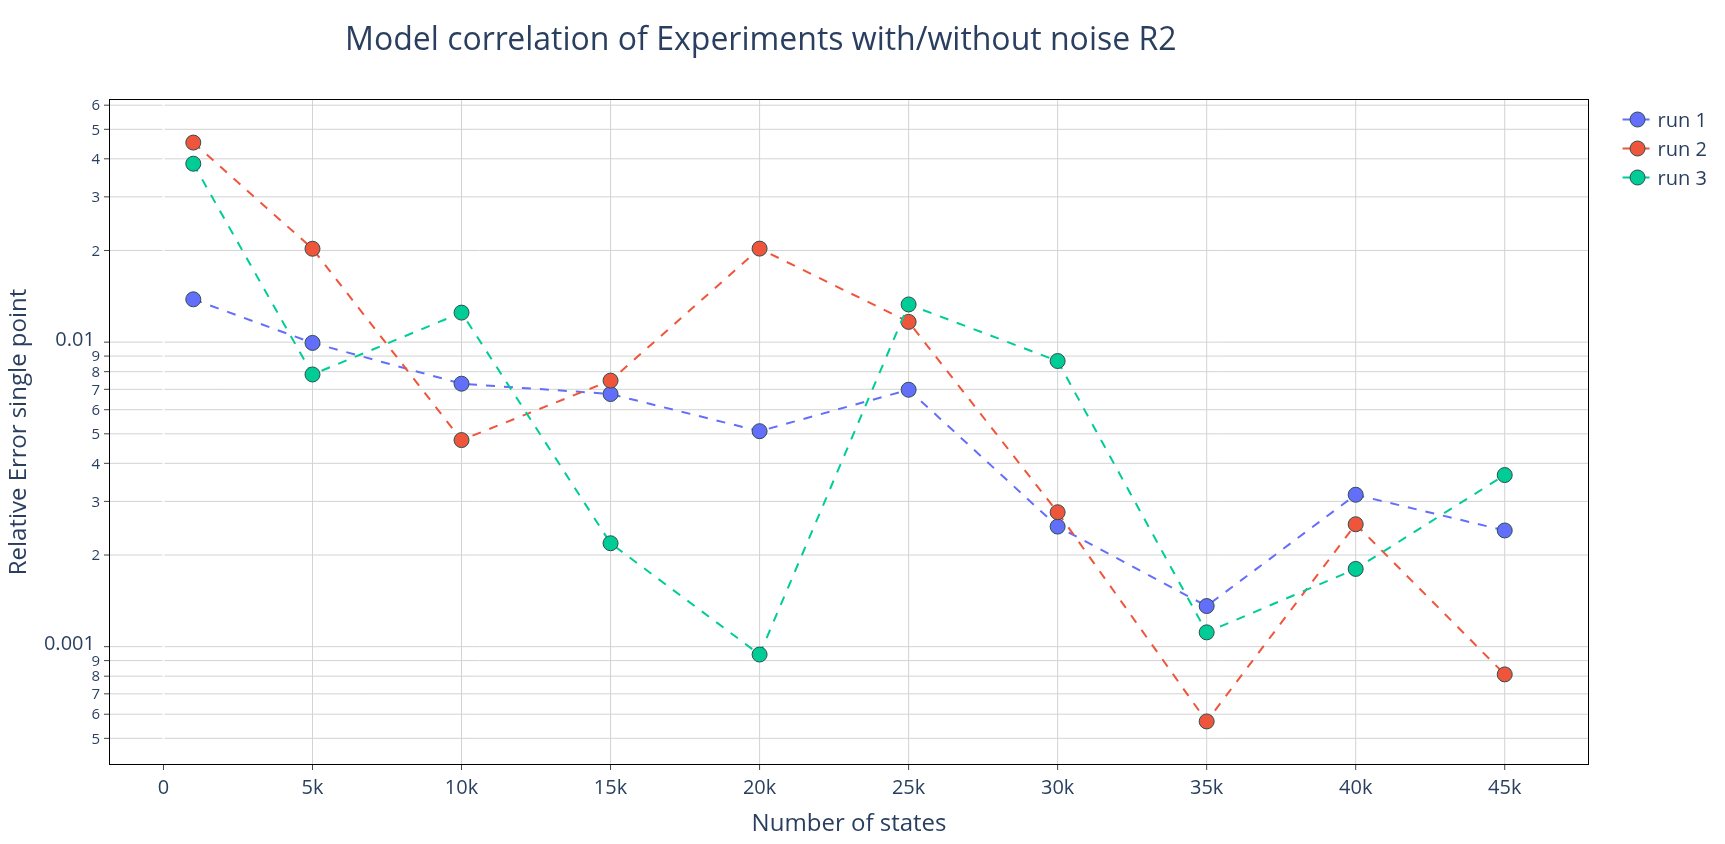

In [24]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_single_pt['Nstates'], 
        y=df_single_pt['run 1'], 
        mode='lines+markers', 
        name='run 1',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=df_single_pt['Nstates'], 
        y=df_single_pt['run 2'], 
        mode='lines+markers', 
        name='run 2',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x=df_single_pt['Nstates'], 
        y=df_single_pt['run 3'], 
        mode='lines+markers', 
        name='run 3',
        line=dict(dash='dash')
    ),
    row=1, col=1
)


fig.update_traces(marker=dict(size=15, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise R2",
        'font': {'size': 32},
        'x' :0.2
    },
    #title_text="Root Mean Squared Error"
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'

)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    linecolor='black',
    gridcolor='lightgrey',
    type='log',
    title_text='Relative Error in a single point'
)
fig.show()



## Problems with $R{2}$

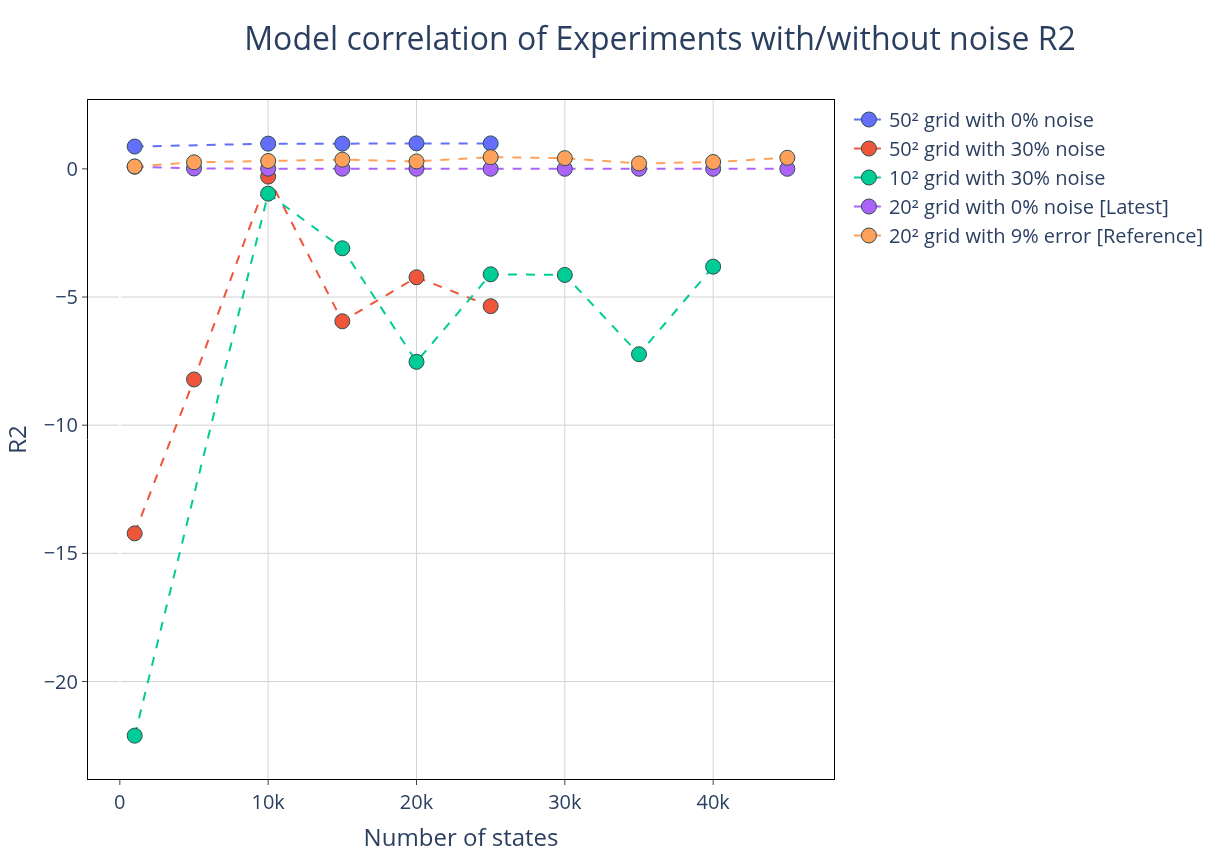

In [20]:
# Configuración del subplot
fig = make_subplots(
    rows=1, 
    cols=1, 
     # Actualizado para que coincida con tus datos
)

# Agregar la primera fila (row=1)
fig.add_trace(
    go.Scatter(
        x=df_50_pure['Nstates'], 
        y=df_50_pure['R2'], 
        mode='lines+markers', 
        name='50² grid with 0% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la segunda fila (row=2)
fig.add_trace(
    go.Scatter(
        x=df_50_error['Nstates'], 
        y=df_50_error['R2'], 
        mode='lines+markers', 
        name='50² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)

# Agregar la tercera fila (row=3)
fig.add_trace(
    go.Scatter(
        x=df_10_error['Nstates'], 
        y=df_10_error['R2'], 
        mode='lines+markers', 
        name='10² grid with 30% noise',
        line=dict(dash='dash')
    ),
    row=1, col=1
)
fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 0.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 0.0, 'R2'],
    name="20² grid with 0% noise [Latest]",
    mode='lines+markers',
    line=dict(dash='dash')
))

fig.add_trace(go.Scatter(
    x = results_df.loc[results_df['Noise'] == 9.0, 'N_states'],
    y = results_df.loc[results_df['Noise'] == 9.0, 'R2'],
    name="20² grid with 9% error [Reference]",
    mode='lines+markers',
    line=dict(dash='dash')
))


fig.update_traces(marker=dict(size=15, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    height = 844,
    width = 1500,
    font=dict(size=20),
    paper_bgcolor='white',
    plot_bgcolor='white',
    title={
        'text': "Model correlation of Experiments with/without noise R2",
        'font': {'size': 32},
        'x' :0.2
    },
    #title_text="Root Mean Squared Error"
)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    title_text='Number of states'

)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    linecolor='black',
    gridcolor='lightgrey',
    #type='log',
    title_text='R2'
)
fig.show()



## Data Standarization via Zscale

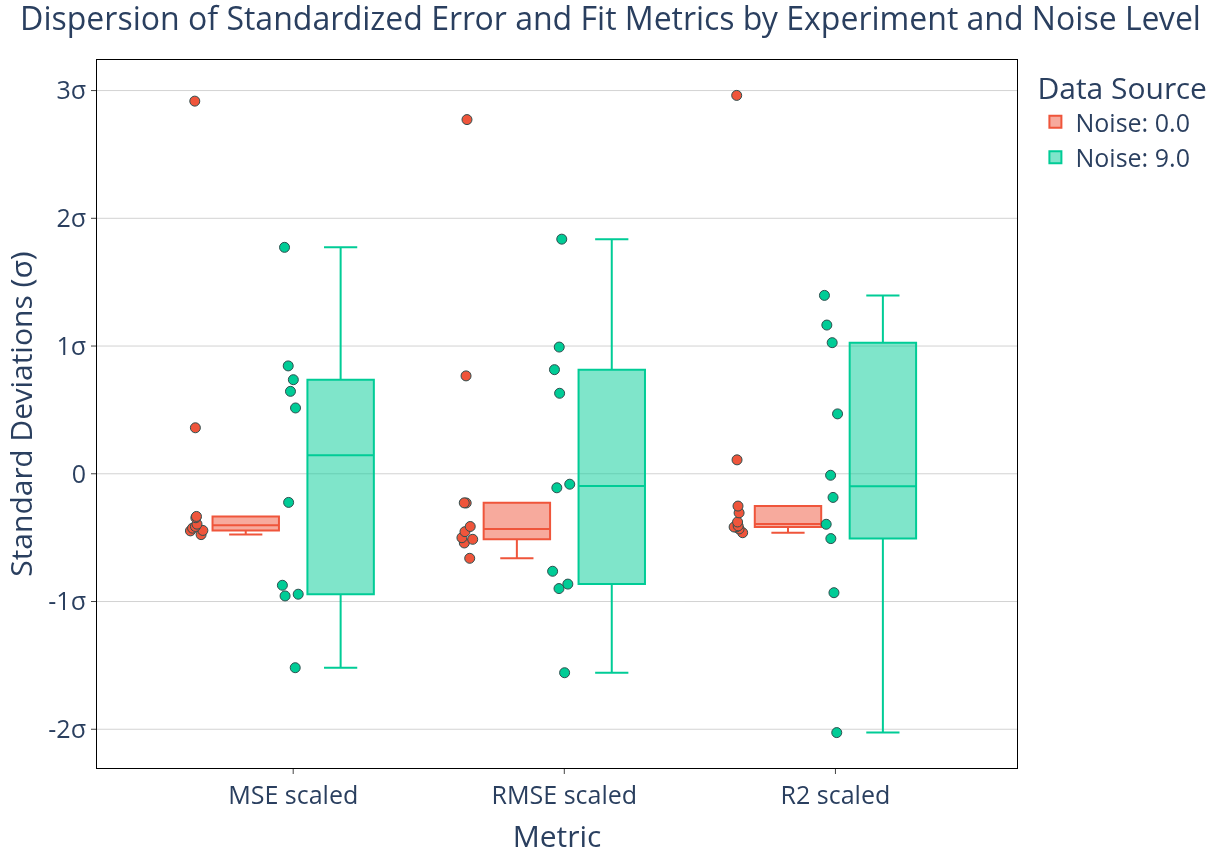

In [21]:
# 1. Prepare the scaled experiments DataFrame (from the previous step)
df_experiments = scaled_results.copy()
# Rename the 'Experiment' column to our unified 'Group' column
df_experiments.rename(columns={'Experiment': 'Group'}, inplace=True)

# 2. Prepare your existing results_df (the Noise data)
# Isolate just the scaled columns and the Noise column
df_noise = results_df[['MSE scaled', 'RMSE scaled', 'R2 scaled', 'Noise']].copy()
# Create the unified 'Group' column by adding a prefix to the noise levels so they stand out
df_noise['Group'] = 'Noise: ' + df_noise['Noise'].astype(str)
# We no longer need the 'Noise' column since it's now in 'Group'
df_noise = df_noise.drop(columns=['Noise'])

# 3. Concatenate everything into one master DataFrame
final_combined_df = pd.concat([df_experiments, df_noise], ignore_index=True)

# 4. Generate the Plot
tick_values = [k for k in range(-3,4)]
tick_labels = ['0' if val == 0 else f'{val}\u03C3' for val in tick_values] # Using unicode for σ

fig = px.box(
    final_combined_df,
    y=['MSE scaled', 'RMSE scaled', 'R2 scaled'],
    color='Group', # Now grouping by our unified column
    points='all',
    height=844,
    width=1500,
)

# Styling traces
fig.update_traces(
    marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')),
    selector=dict(type='box')
)

# Styling layout
fig.update_layout(
    title={
        'text': "Dispersion of Standardized Error and Fit Metrics by Experiment and Noise Level",
        'font': {'size': 32},
        'x': 0.5
    },
    font=dict(size=25),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend_title_text='Data Source' # Updated legend title
)

# Styling X-axis
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    title_text='Metric',
)

# Styling Y-axis
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    zerolinecolor='LightGray', 
    zerolinewidth=1,
    linecolor='black',
    gridcolor='lightgrey',
    tickmode='array', 
    tickvals=tick_values,
    ticktext=tick_labels,
    title_text='Standard Deviations (\u03C3)'
)

fig.show()

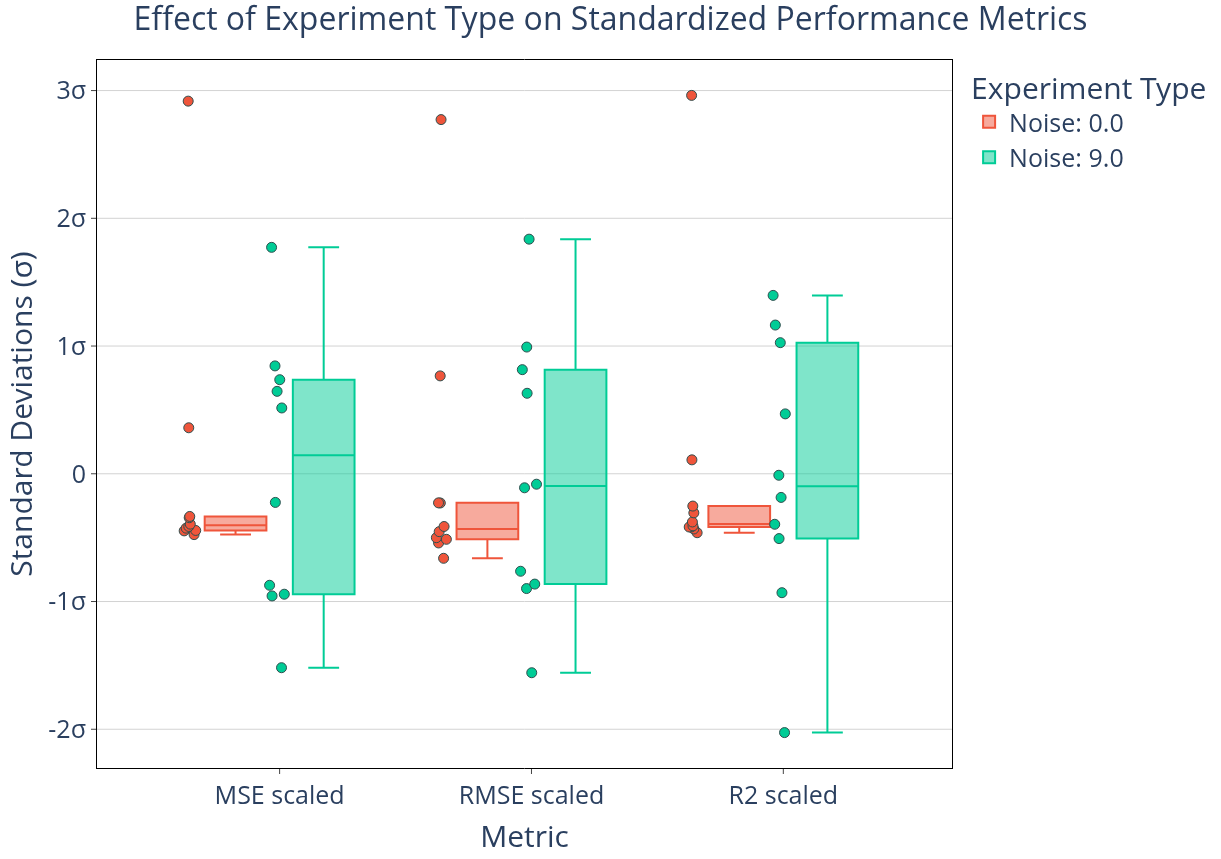

In [22]:
# Set up custom ticks for standard deviations
tick_values = [k for k in range(-3,4)]
tick_labels = ['0' if val == 0 else f'{val}σ' for val in tick_values]

# Generate the plot
fig = px.box(
    final_combined_df,
    y=['MSE scaled', 'RMSE scaled', 'R2 scaled'],
    color='Group',  # Grouping by our new label
    points='all',
    height=844,
    width=1500,
)

# Styling traces
fig.update_traces(
    marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')),
    selector=dict(type='box')
)

# Styling layout
fig.update_layout(
    title={
        'text': "Effect of Experiment Type on Standardized Performance Metrics",
        'font': {'size': 32},
        'x': 0.5
    },
    font=dict(size=25),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend_title_text='Experiment Type' # Clarify the legend
)

# Styling X-axis
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    title_text='Metric',
)

# Styling Y-axis
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    zeroline=True,
    zerolinecolor='LightGray', 
    zerolinewidth=1,
    linecolor='black',
    gridcolor='lightgrey',
    tickmode='array', 
    tickvals=tick_values,
    ticktext=tick_labels,
    title_text='Standard Deviations (\u03C3)' # Added y-axis label for clarity
)

fig.show()

## Surface Plots

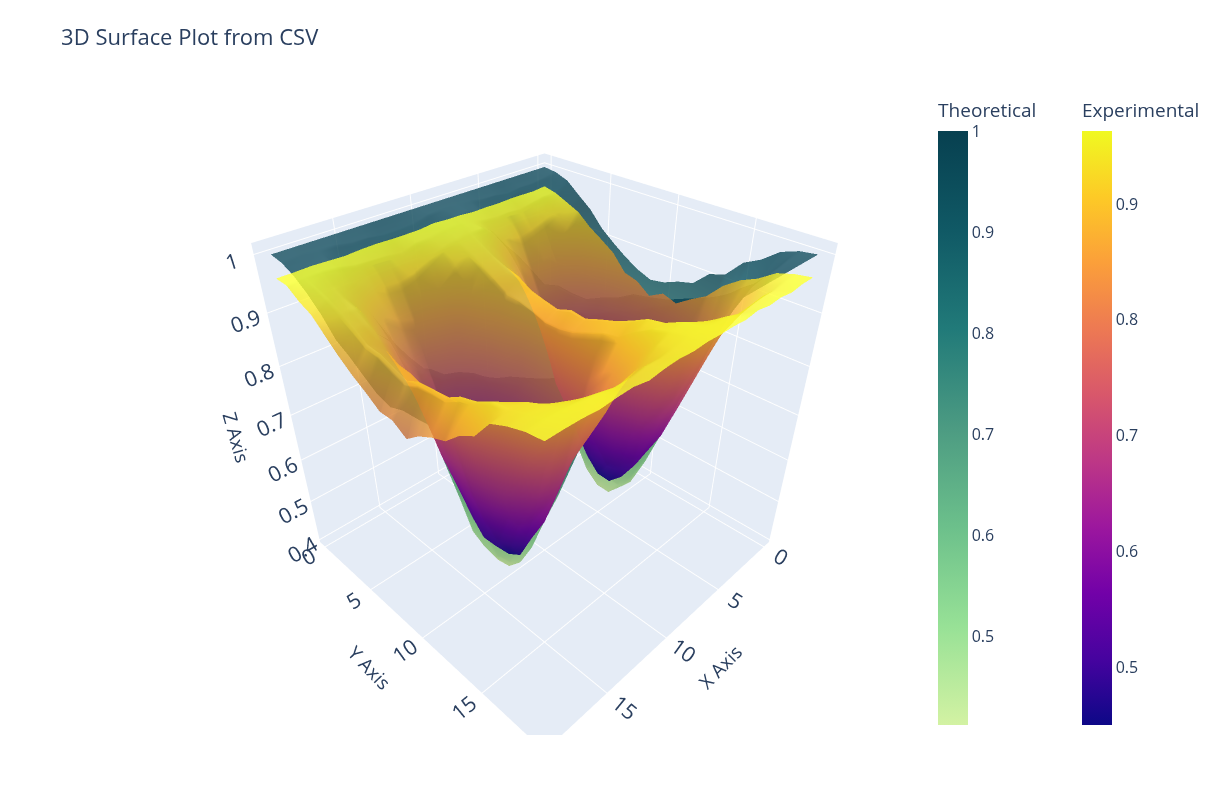

In [23]:
N_data=20

theta_FSS = np.linspace(0,2*pi,N_data)
beta_angle = np.linspace(0,pi,N_data)
alpha = pi/16

experiment_number = 1
model = np.array([[analytical(theta=t,beta=b, alpha=alpha) for b in beta_angle] for t in theta_FSS])

experiment_noiseless = pd.read_csv('./runs/'+'3_E91_data_20x20_mesh_1.5E+04_states_AER_SIM_14_03_2026_18_45_25'+'.csv', header=None).dropna(axis=1,how='all').values
experiment_noisy = pd.read_csv('./runs/'+'3_NOISY_20x20_mesh_1.5E+04_states_AER_SIM_19_03_2026_09_56_15'+'.csv', header=None).dropna(axis=1,how='all').values
#print (f"R2 = {r2(y_true=model,y_pred=experiment)}")
fig = go.Figure()
fig.add_trace(go.Surface(
    z=experiment_noiseless, 
    colorscale='Emrld',
    opacity=.8,
    name='Model',
    colorbar=dict(title='Theoretical', x=0.9)
))


fig.add_trace(go.Surface(
    z=experiment_noisy, 
    #colorscale='Reds',
    opacity=0.8, # Transparency helps see where they intersect
    name='Experimental',
    colorbar=dict(title='Experimental', x=1.05)
))
# Customize the layout for better visualization
fig.update_layout(
    title='3D Surface Plot from CSV',
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        xaxis_title='X Axis',
        yaxis_title='Y Axis',
        zaxis_title='Z Axis'
    ),
    # --- NUEVO: Aumentar tamaño de fuente ---
    font=dict(size=16) 
)

# Display the plot
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Surface(
    z=np.square(model - experiment_noiseless), 
    colorscale='Emrld',
    opacity=.8,
    name='Noiseless',
    colorbar=dict(title='value', x=0.9)
))
# Customize the layout for better visualization
fig.update_layout(
    title=f"Noiseless Experiment Square residuals\rμ={np.mean(np.square(model - experiment_noiseless)):.2e}",
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        xaxis_title='θs',
        yaxis_title='β',
        zaxis_title='(y-y_{t})^{2}'
    ),
    # --- NUEVO: Aumentar tamaño de fuente ---
    font=dict(size=16) 
)

# Display the plot
fig.show()

In [ ]:
fig = go.Figure()
fig.add_trace(go.Surface(
    z=np.square(model - experiment_noisy), 
    colorscale='Emrld',
    opacity=.8,
    name='Model',
    colorbar=dict(title='Value', x=0.9)
))
# Customize the layout for better visualization
fig.update_layout(
    title=f"Noisy Experiment Square residuals\rμ={np.mean(np.square(model - experiment_noisy)):.2e}",
    autosize=False,
    width=800,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        xaxis_title='θ',
        yaxis_title='β',
        zaxis_title='(y-y_{t})^{2}'
    ),
    # --- NUEVO: Aumentar tamaño de fuente ---
    font=dict(size=16) 
)

# Display the plot
fig.show()